1. IMPORT LIBRARIES

In [6]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns

from sklearn.cluster import KMeans
from sklearn.metrics import silhouette_score
from sklearn.preprocessing import StandardScaler
from sklearn.model_selection import train_test_split
from sklearn.ensemble import RandomForestClassifier
from sklearn.metrics import accuracy_score, classification_report

2. LOAD DATA

In [3]:
df = pd.read_csv('data.csv', encoding='latin1')
df.head()

,InvoiceNo,StockCode,Description,Quantity,InvoiceDate,UnitPrice,CustomerID,Country
0,536365,85123A,WHITE HANGING HEART T-LIGHT HOLDER,6,12/1/2010 8:26,2.55,17850.0,United Kingdom
1,536365,71053,WHITE METAL LANTERN,6,12/1/2010 8:26,3.39,17850.0,United Kingdom
2,536365,84406B,CREAM CUPID HEARTS COAT HANGER,8,12/1/2010 8:26,2.75,17850.0,United Kingdom
3,536365,84029G,KNITTED UNION FLAG HOT WATER BOTTLE,6,12/1/2010 8:26,3.39,17850.0,United Kingdom
4,536365,84029E,RED WOOLLY HOTTIE WHITE HEART.,6,12/1/2010 8:26,3.39,17850.0,United Kingdom


3. DATA CLEANING

In [7]:
df = df.dropna(subset=['CustomerID'])
df = df[df['Quantity'] > 0]
df = df[df['UnitPrice'] > 0]

df['InvoiceDate'] = pd.to_datetime(df['InvoiceDate'])

4. FEATURE ENGINEERING

In [5]:
df['TotalPrice'] = df['Quantity'] * df['UnitPrice']
df[['InvoiceNo', 'Quantity', 'UnitPrice', 'CustomerID', 'TotalPrice']].head()

,InvoiceNo,Quantity,UnitPrice,CustomerID,TotalPrice
0,536365,6,2.55,17850.0,15.30
1,536365,6,3.39,17850.0,20.34
2,536365,8,2.75,17850.0,22.00
3,536365,6,3.39,17850.0,20.34
4,536365,6,3.39,17850.0,20.34


5. UNIVARIATE ANALYSIS

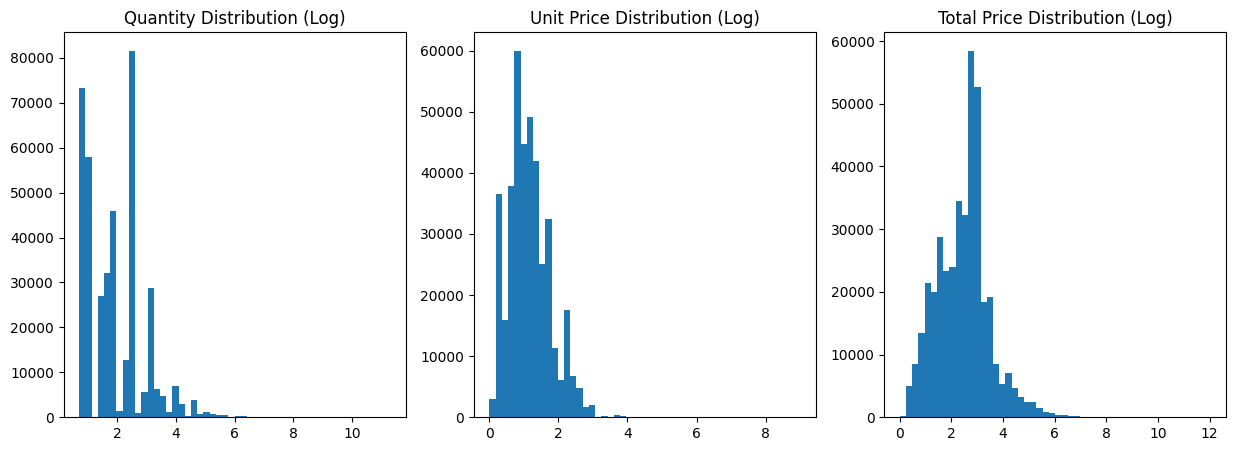

In [ ]:
plt.figure(figsize=(15,5))

plt.subplot(1,3,1)
plt.hist(np.log1p(df['Quantity']), bins=50)
plt.title("Quantity Distribution (Log)")

plt.subplot(1,3,2)
plt.hist(np.log1p(df['UnitPrice']), bins=50)
plt.title("Unit Price Distribution (Log)")

plt.subplot(1,3,3)
plt.hist(np.log1p(df['TotalPrice']), bins=50)
plt.title("Total Price Distribution (Log)")

plt.show()

6. RFM CREATION

In [ ]:
snapshot_date = df['InvoiceDate'].max() + pd.Timedelta(days=1)

rfm = df.groupby('CustomerID').agg({
    'InvoiceDate': lambda x: (snapshot_date - x.max()).days,
    'InvoiceNo': 'nunique',
    'TotalPrice': 'sum'
})

rfm.columns = ['Recency', 'Frequency', 'Monetary']
rfm = rfm.reset_index()

7. RFM DISTRIBUTION

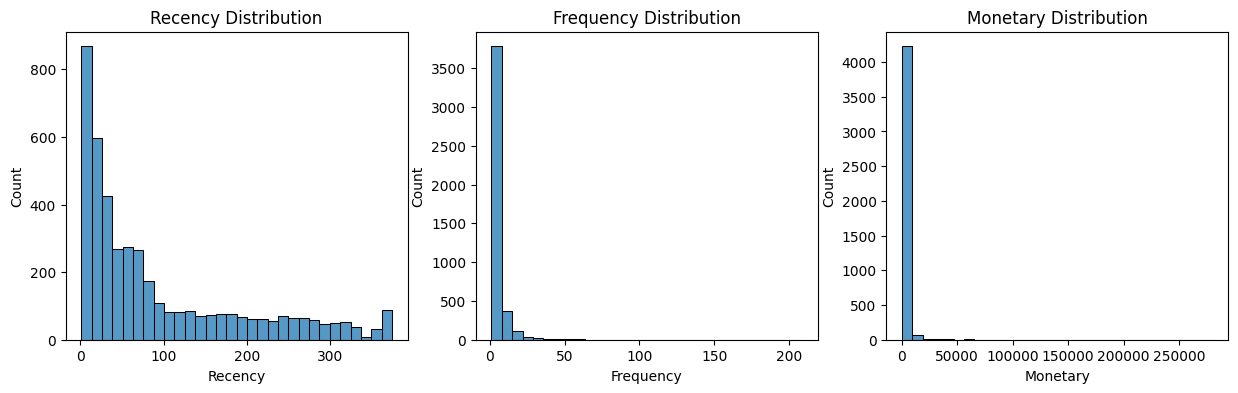

In [ ]:
plt.figure(figsize=(15,4))

plt.subplot(1,3,1)
sns.histplot(rfm['Recency'], bins=30)
plt.title('Recency Distribution')

plt.subplot(1,3,2)
sns.histplot(rfm['Frequency'], bins=30)
plt.title('Frequency Distribution')

plt.subplot(1,3,3)
sns.histplot(rfm['Monetary'], bins=30)
plt.title('Monetary Distribution')

plt.show()

 8. BIVARIATE ANALYSIS

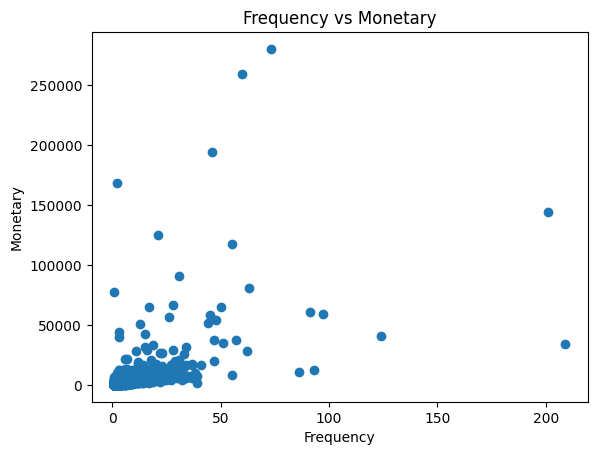

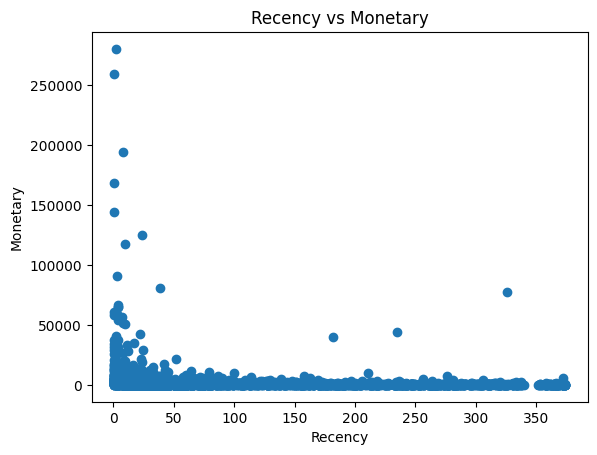

In [ ]:
plt.figure()
plt.scatter(rfm['Frequency'], rfm['Monetary'])
plt.title('Frequency vs Monetary')
plt.xlabel('Frequency')
plt.ylabel('Monetary')
plt.show()

plt.figure()
plt.scatter(rfm['Recency'], rfm['Monetary'])
plt.title('Recency vs Monetary')
plt.xlabel('Recency')
plt.ylabel('Monetary')
plt.show()


9. FEATURE SCALING

In [ ]:
X = rfm[['Recency', 'Frequency', 'Monetary']]

scaler = StandardScaler()
X_scaled = scaler.fit_transform(X)


10. ELBOW METHOD

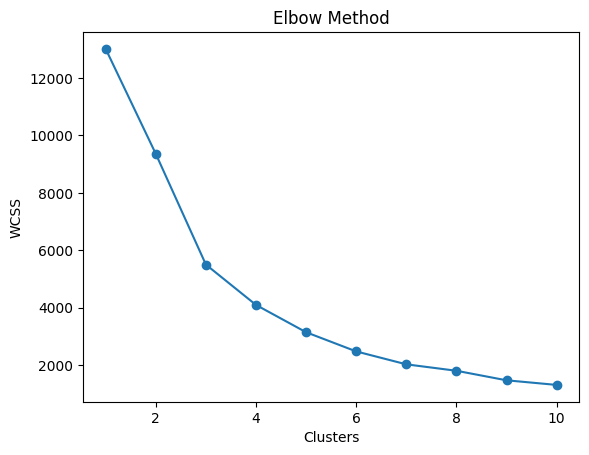

In [ ]:
wcss = []

for i in range(1, 11):
    kmeans = KMeans(n_clusters=i, random_state=42)
    kmeans.fit(X_scaled)
    wcss.append(kmeans.inertia_)

plt.figure()
plt.plot(range(1, 11), wcss, marker='o')
plt.title('Elbow Method')
plt.xlabel('Clusters')
plt.ylabel('WCSS')
plt.show()

11. K-MEANS CLUSTERING

In [ ]:
kmeans = KMeans(n_clusters=3, random_state=42)
rfm['Cluster'] = kmeans.fit_predict(X_scaled)


12. CLUSTER VISUALIZATION

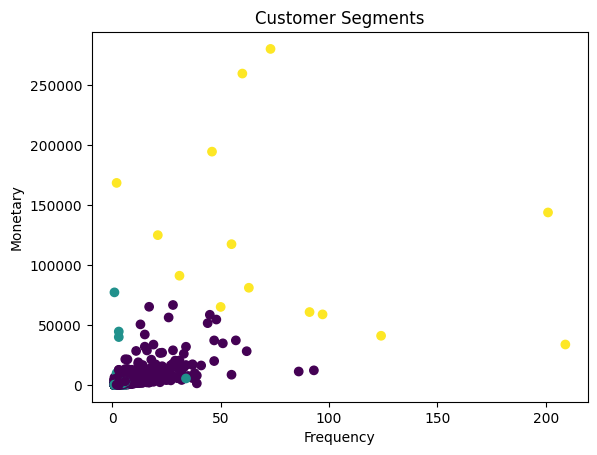

In [ ]:
plt.figure()
plt.scatter(rfm['Frequency'], rfm['Monetary'], c=rfm['Cluster'])
plt.title('Customer Segments')
plt.xlabel('Frequency')
plt.ylabel('Monetary')
plt.show()

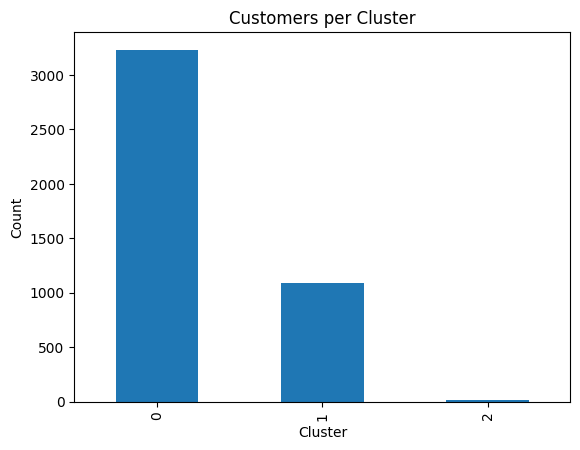

In [ ]:
rfm['Cluster'].value_counts().plot(kind='bar')
plt.title('Customers per Cluster')
plt.xlabel('Cluster')
plt.ylabel('Count')
plt.show()


13. CLUSTER INTERPRETATION

In [ ]:
print("\nCluster Summary:")
print(rfm.groupby('Cluster')[['Recency', 'Frequency', 'Monetary']].mean())



Cluster Summary:
            Recency  Frequency       Monetary
Cluster                                      
0         40.983906   4.852677    2012.111620
1        246.023788   1.582800     631.141410
2          7.142857  80.214286  122888.407143


14. MODEL EVALUATION

In [ ]:
score = silhouette_score(X_scaled, rfm['Cluster'])
print("\nSilhouette Score:", score)



Silhouette Score: 0.5852924318247733


15. PREDICTION MODEL

In [ ]:
X = rfm[['Recency', 'Frequency', 'Monetary']]
y = rfm['Cluster']

X_train, X_test, y_train, y_test = train_test_split(
    X, y, test_size=0.2, random_state=42
)

model = RandomForestClassifier(random_state=42)
model.fit(X_train, y_train)

y_pred = model.predict(X_test)

print("\nPrediction Model Accuracy:", accuracy_score(y_test, y_pred))
print("\nClassification Report:\n", classification_report(y_test, y_pred))


Prediction Model Accuracy: 0.9965437788018433

Classification Report:
               precision    recall  f1-score   support

           0       1.00      1.00      1.00       635
           1       0.99      1.00      1.00       229
           2       1.00      0.75      0.86         4

    accuracy                           1.00       868
   macro avg       1.00      0.92      0.95       868
weighted avg       1.00      1.00      1.00       868

